In [1]:
#%reset -f
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

import seaborn as sns
%matplotlib inline

import math
from math import(e)

In [3]:
listIndex = ['RWI', 'MNDWI', 'NDWI', 'AWEInsh', 'AWEIsh']
listIndexB = ['RWI', 'MNDWI', 'NDWI']
listCity = ['Sao Paulo', 'Curitiba', 'Florianopolis', 'Porto Alegre', 'Buenos Aires', 'Vina del Mar']

In [35]:
import os
path = 'C:\\Users\\eduju\\OneDrive\\Documentos\\Doutorado\\artigos\\ÍndiceÁgua\\ArcGis\\exportFromGEE'
#os.listdir(path)
os.chdir(path)

df_SR = pd.read_csv('samplePointsCities_20250303_harmonized.csv', sep=',', decimal='.')
df_SR.replace([np.inf, -np.inf], np.nan, inplace=True)

df_SR['classWat'] = df_SR['classWat'].astype(str).replace({'shadow': 'non-water shaded'})
df_SR['color'] = df_SR['color'].astype(str).replace({'nan': 'none'})

def reclassify(value):
    if value == 'water':
        return 1
    if value != 'water':
        return 0

df_SR['surfClass'] = df_SR['surface'].apply(reclassify)

print('Sample points: ',len(df_SR))
print()
print(df_SR[df_SR['surface'] == 'water'].head(1))

print(df_SR.sort_values(by='rand_point', ascending=False))

Sample points:  123754

       B1      B2      B3      B4      B5      B6      B7      B8     B8A  \
0  0.0516  0.0813  0.0954  0.0925  0.0942  0.0573  0.0517  0.0418  0.0333   

      B11     B12          city surface         classWat  rand_point color  \
0  0.0195  0.0123  Buenos Aires   water  artificial pond         534  none   

   shadow  surfClass  
0     NaN          1  
            B1      B2      B3      B4      B5      B6      B7      B8  \
14364   0.0582  0.1023  0.1092  0.1282  0.0904  0.0998  0.0779  0.1278   
106891  0.1080  0.1220  0.1298  0.1510  0.2029  0.2007  0.1811  0.1610   
106890  0.0612  0.0586  0.0752  0.0911  0.1154  0.1302  0.1472  0.1516   
62956   0.0557  0.0171  0.0383  0.0206  0.0787  0.2557  0.3119  0.3452   
90170   0.0556  0.0520  0.0592  0.0755  0.0712  0.0783  0.0953  0.1208   
...        ...     ...     ...     ...     ...     ...     ...     ...   
15559   0.0361  0.0098  0.0084  0.0105  0.0521  0.0646  0.0887  0.0233   
40185   0.0699  0.0003  0.

C:\Users\eduju\AppData\Local\Temp\ipykernel_2428\4135578254.py:6: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_SR = pd.read_csv('samplePointsCities_20250303_harmonized.csv', sep=',', decimal='.')


### Indices calc

In [37]:
def powe(number):
    return number ** (1 / e)

In [39]:
df_SR['B3Pow']     = df_SR['B3'].apply(powe)

df_SR['RWI'] = 0
df_SR['NDWI']    = (df_SR['B3'] - df_SR['B8'])         / (df_SR['B3'] + df_SR['B8'])
df_SR['MNDWI']   = (df_SR['B3'] - df_SR['B11'])        / (df_SR['B3'] + df_SR['B11'])
#df_SR['RWI']  = (df_SR['B3Pow'] - df_SR['B11'])     / (df_SR['B3Pow'] + df_SR['B11'])

 # AWEIsh =            blue     + 2.5 x    green    - 1.5 x (   Nir      +     Swir1   ) - 0.25 x   Swir2
df_SR['AWEIsh']   = df_SR['B2'] + 2.5 * df_SR['B3'] - 1.5 * (df_SR['B8'] + df_SR['B11']) - 0.25 * df_SR['B12']
 # AWEInsh        = 4 x (   green    -    Swir1    ) - (0.25 x      Nir    + 2.75 x    Swir2    )
df_SR['AWEInsh']  = 4 * (df_SR['B3'] - df_SR['B11']) - (0.25 * df_SR['B8'] + 2.75 * df_SR['B12'])
df_SR['code'] = range(1, len(df_SR) + 1)

#print(df_SR.head(1))

In [41]:
cityValue = {}

for city in listCity:
    cityValue[city] = df_SR[df_SR['city'] == city]['B3Pow'].median() / df_SR[df_SR['city'] == city]['B3'].median()

print(cityValue)

df_SR['divider'] = df_SR['city'].map(cityValue)
df_SR['B3powDiv']  = df_SR['B3Pow'] / df_SR['divider']

df_SR['RWI'] = (df_SR['B3powDiv'] - df_SR['B11']) / (df_SR['B3powDiv'] + df_SR['B11'])

print('____________________')

#df_SR.to_excel('df_SR.xlsx') 

unique_cities = df_SR['divider'].unique()
#print(df_SR.head(1))

{'Sao Paulo': 5.828770268246491, 'Curitiba': 5.85892560490295, 'Florianopolis': 5.877213189872267, 'Porto Alegre': 5.672592996509505, 'Buenos Aires': 5.874154562654084, 'Vina del Mar': 5.2392623813178965}
____________________


In [43]:
classWat = ['artificial pond', 'artificial pond with algae', 'coastal wetland', 'lake', 'polluted river',
            'reservoir', 'river', 'river mouth', 'seashore - Vinal del Mar', 'seashore - Florianopolis', 'non-water shaded', 'water treatment plant', 'non-water']

classNonWat = ['non-water shaded', 'non-water']
listColor = ['brown', 'dark', 'dark gray', 'dark green', 'green']
color2 = {'brown': 'brown', 'dark': 'black', 'dark gray':'gray', 'dark green':'darkgreen', 'green':'green'}

In [45]:
colorClassWat = {
    'artificial pond':'navajowhite',
    'artificial pond with algae':'lime',
    'coastal wetland':'darkkhaki',
    'lake':'lightsteelblue',
    'polluted river':'indianred',
    'reservoir':'c',
    'river':'cyan',
    'river mouth':'olive',
    'seashore - Vina del Mar':'cyan',
    'seashore - Florianopolis':'dodgerblue',
    'water treatment plant':'goldenrod',
    'non-water':'red',
    'non-water shaded': 'black'
    }

markers = {
    'artificial pond':'p',
    'artificial pond with algae':'p',
    'coastal wetland':'*',
    'lake':'s',
    'polluted river':'x',
    'reservoir':'s',
    'river':'s',
    'river mouth':'*',
    'seashore - Vina del Mar':"d",
    'seashore - Florianopolis':"d",
    'water treatment plant':'o',
    'non-water':'o',
    'non-water shaded': 'v'
}

sizes = {
    'artificial pond':8,
    'artificial pond with algae':8,
    'coastal wetland':8,
    'lake':7,
    'polluted river':10,
    'reservoir':7,
    'river':7,
    'river mouth':8,
    'seashore - Vina del Mar':8,
    'seashore - Florianopolis':8,
    'water treatment plant':7,
    'non-water':6,
    'non-water shaded': 6
}

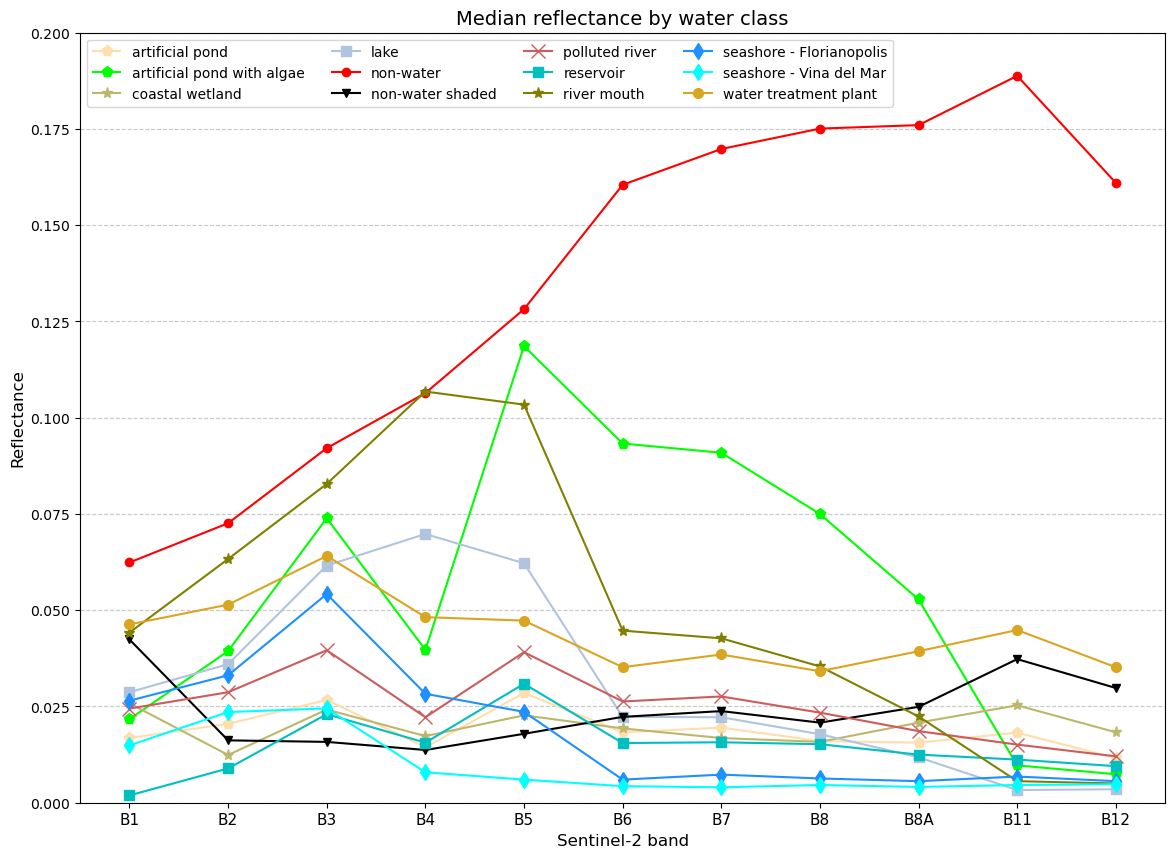

In [51]:
bands = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']

df_SR['classWat'] = df_SR.apply(lambda row: 'non-water shaded' if row['shadow'] == 1 else row['classWat'], axis=1) 
#dfclassWat = df_SR.loc[df_SR['non-water shaded'] == 1, 'classWat'] = 'non-water shaded'

dfclassWat = df_SR[df_SR['classWat'] != 'noSelection']
dfclassWat = dfclassWat[dfclassWat['classWat'] != 'river']
#print(dfclassWat)
dfclassWat_Mean = dfclassWat.groupby('classWat')[bands].median()
#print(dfclassWat_Mean)

# Criando posições para as barras

sorted_classes = sorted(dfclassWat_Mean.index)

fig, ax = plt.subplots(figsize=(14, 10))

x = np.arange(len(bands))
width = 0.25  # Largura das barras

for color in dfclassWat_Mean.index:
    plt.plot(bands, dfclassWat_Mean.loc[color], marker=markers[color], markersize=sizes[color], linestyle='-', label=color, color=colorClassWat[color])

ax.set_xticks(x)
ax.set_xticklabels(bands, fontsize=11)
ax.set_xlabel('Sentinel-2 band', fontsize=12)
ax.set_ylabel('Reflectance', fontsize=12)
ax.set_title('Median reflectance by water class', fontsize=14)
ax.legend(title="Water Class")
ax.grid(axis='y', linestyle='--', alpha=0.7)
#plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize = 14, ncol=2)
plt.legend(loc="upper left", fontsize = 10, ncol=4)
plt.ylim(0, 0.2)
plt.savefig('refletance', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

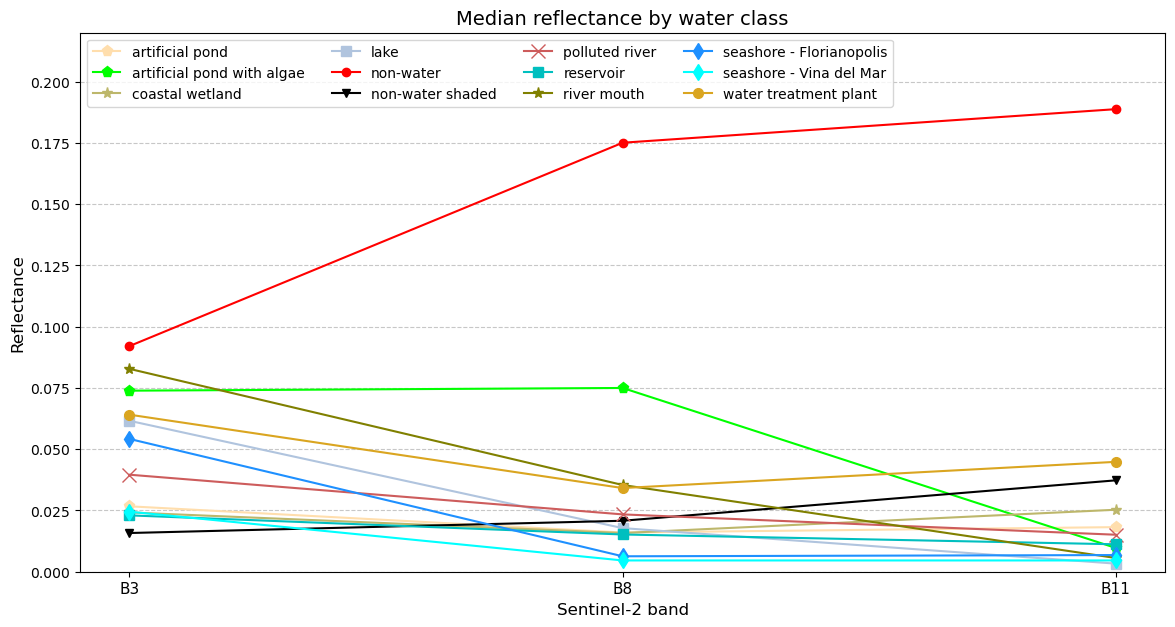

In [53]:
bands = ['B3', 'B8', 'B11']

df_SR['classWat'] = df_SR.apply(lambda row: 'non-water shaded' if row['shadow'] == 1 else row['classWat'], axis=1) 
#dfclassWat = df_SR.loc[df_SR['non-water shaded'] == 1, 'classWat'] = 'non-water shaded'

dfclassWat = df_SR[df_SR['classWat'] != 'noSelection']
dfclassWat = dfclassWat[dfclassWat['classWat'] != 'river']
#print(dfclassWat)
dfclassWat_Mean = dfclassWat.groupby('classWat')[bands].median()
#print(dfclassWat_Mean)

# Criando posições para as barras

sorted_classes = sorted(dfclassWat_Mean.index)

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(bands))
width = 0.25  # Largura das barras

for color in dfclassWat_Mean.index:
    plt.plot(bands, dfclassWat_Mean.loc[color], marker=markers[color], markersize=sizes[color], linestyle='-', label=color, color=colorClassWat[color])

ax.set_xticks(x)
ax.set_xticklabels(bands, fontsize=11)
ax.set_xlabel('Sentinel-2 band', fontsize=12)
ax.set_ylabel('Reflectance', fontsize=12)
#ax.set_yticks([0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14])
ax.set_title('Median reflectance by water class', fontsize=14)
ax.legend(title="Water Class")
ax.grid(axis='y', linestyle='--', alpha=0.7)
#plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize = 14, ncol=2)
plt.legend(loc="upper left", fontsize = 10, ncol=4)
plt.ylim(0, 0.22)
plt.show()

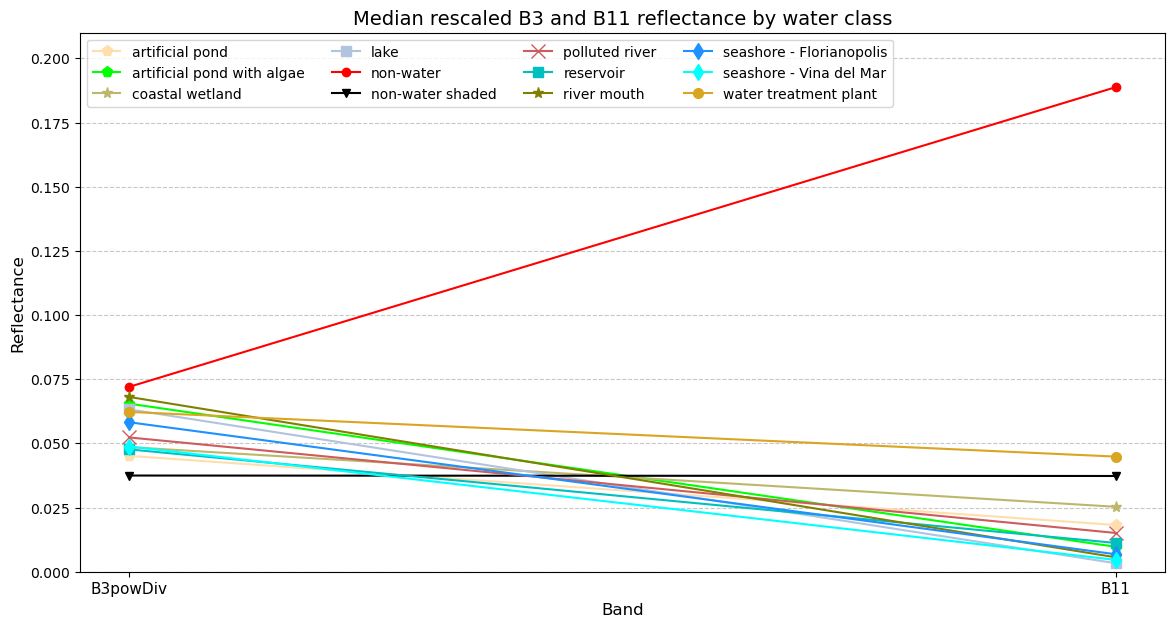

In [55]:
bands = ['B3powDiv', 'B11']

df_SR['classWat'] = df_SR.apply(lambda row: 'non-water shaded' if row['shadow'] == 1 else row['classWat'], axis=1) 
#dfclassWat = df_SR.loc[df_SR['non-water shaded'] == 1, 'classWat'] = 'non-water shaded'

dfclassWat = df_SR[df_SR['classWat'] != 'noSelection']
dfclassWat = dfclassWat[dfclassWat['classWat'] != 'river']
#print(dfclassWat)
dfclassWat_Mean = dfclassWat.groupby('classWat')[bands].median()
#print(dfclassWat_Mean)

# Criando posições para as barras

sorted_classes = sorted(dfclassWat_Mean.index)

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(bands))
width = 0.25  # Largura das barras

for color in dfclassWat_Mean.index:
    plt.plot(bands, dfclassWat_Mean.loc[color], marker=markers[color], markersize=sizes[color], linestyle='-', label=color, color=colorClassWat[color])

ax.set_xticks(x)
ax.set_xticklabels(bands, fontsize=11)
ax.set_xlabel('Band', fontsize=12)
ax.set_ylabel('Reflectance', fontsize=12)
ax.set_title('Median rescaled B3 and B11 reflectance by water class', fontsize=14)
ax.legend(title="Water Class")
ax.grid(axis='y', linestyle='--', alpha=0.7)
#plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize = 14, ncol=2)
plt.legend(loc="upper left", fontsize = 10, ncol=4)
plt.ylim(0, 0.21)
plt.savefig('refletance_B3_modified', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

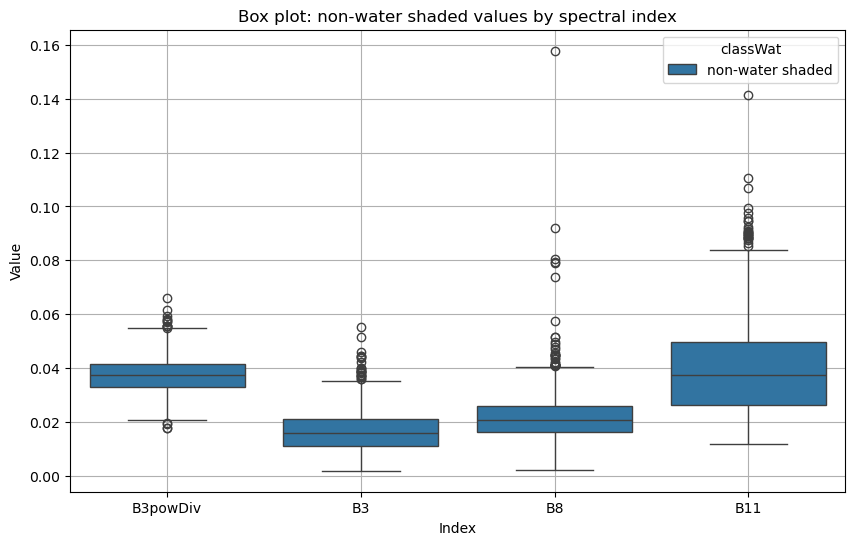

In [57]:
df_SR['classWat'] = df_SR.apply(lambda row: 'non-water shaded' if row['shadow'] == 1 else row['classWat'], axis=1) 

dfclassWat = df_SR[df_SR['classWat'] != 'non-water']
dfclassWat = dfclassWat[dfclassWat['classWat'] == 'non-water shaded']
#dfclassWat = dfclassWat[dfclassWat['city'] == 'Curitiba']
dfclassWat = dfclassWat[['classWat', 'B3powDiv', 'B3', 'B8', 'B11']]
#print(dfclassWat)
df_melted = dfclassWat.melt(id_vars=['classWat'], var_name = 'index', value_name='value')

plt.figure(figsize=(10, 6))
sns.boxplot(x='index', y='value', hue='classWat', data=df_melted)
plt.title('Box plot: non-water shaded values by spectral index')
plt.xlabel('Index')
plt.ylabel('Value')
#plt.legend(title="")
plt.grid(True)
plt.show()

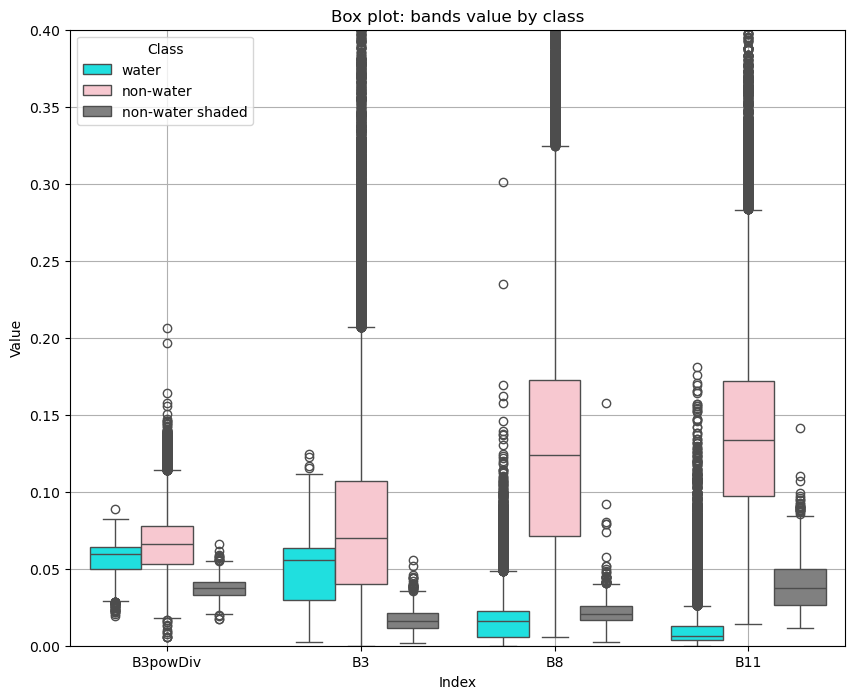

In [59]:
colorBands = {
    'water':'cyan',
    'non-water':'pink',
    'non-water shaded': 'gray'
    }

df_B3 = df_SR

df_B3['class_2'] = np.where(df_B3['surfClass'] == 1, 'water', 'non-water')
df_B3['class_2'] = df_B3.apply(lambda row: 'non-water shaded' if row['shadow'] == 1 else row['class_2'], axis=1) 
#print(df_B3)

dfclassWat = df_B3[['class_2', 'B3powDiv', 'B3', 'B8', 'B11']]

df_melted = dfclassWat.melt(id_vars='class_2', value_vars=['B3powDiv', 'B3', 'B8', 'B11'], var_name = 'band', value_name='value')

plt.figure(figsize=(10, 8))
sns.boxplot(x='band', y='value', hue='class_2', data=df_melted, palette=colorBands)
plt.title('Box plot: bands value by class')
plt.ylim(0, 0.4)
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend(title="Class")
plt.grid(True)
plt.show()

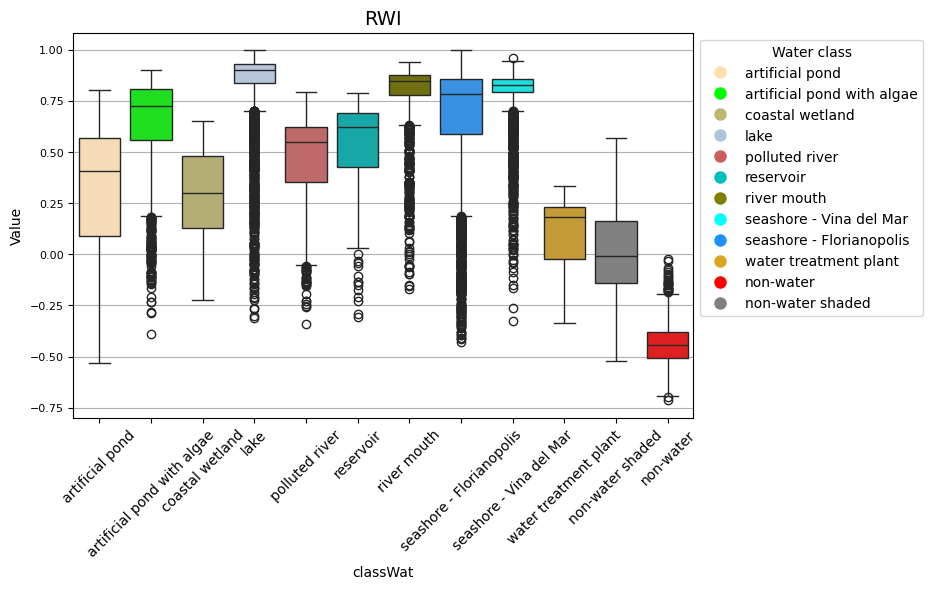

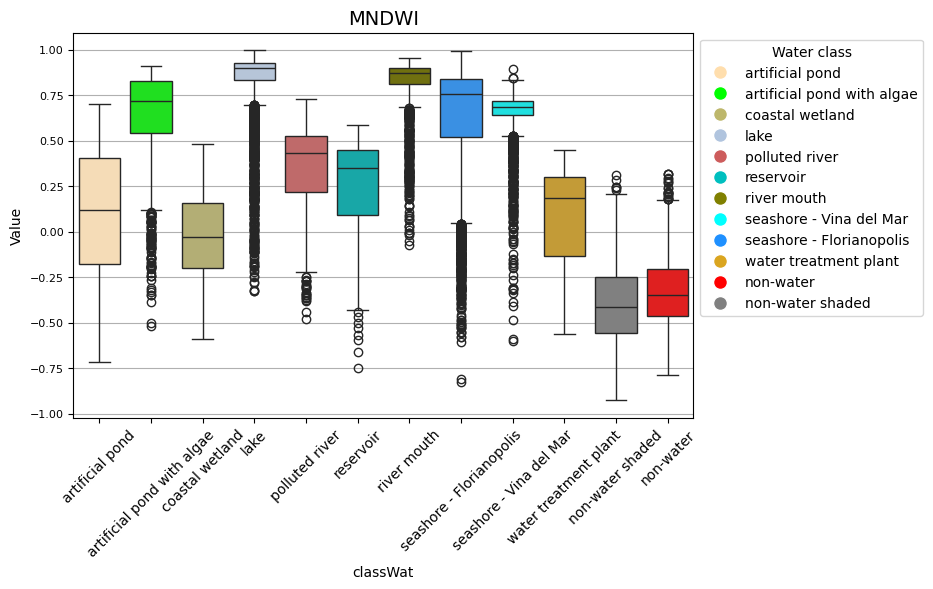

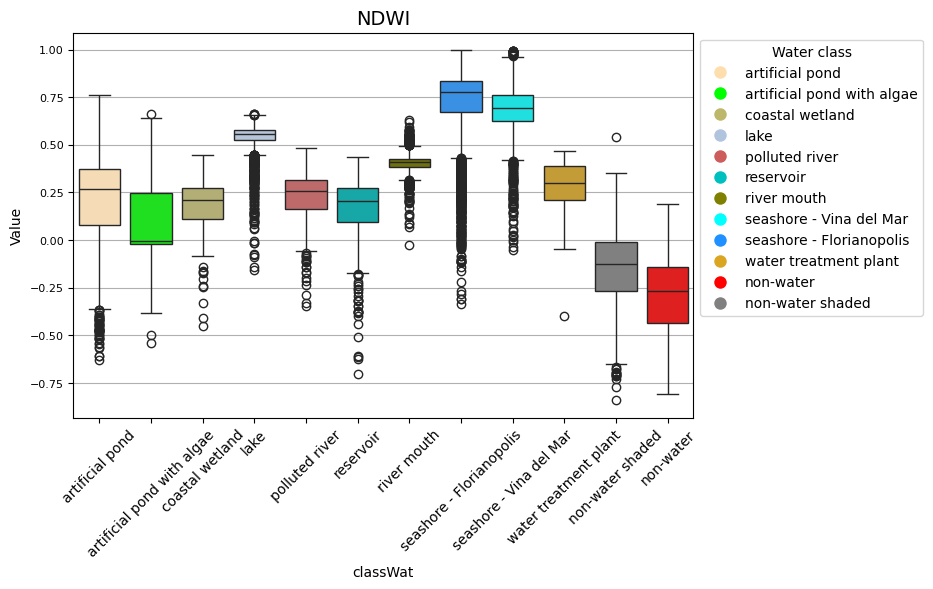

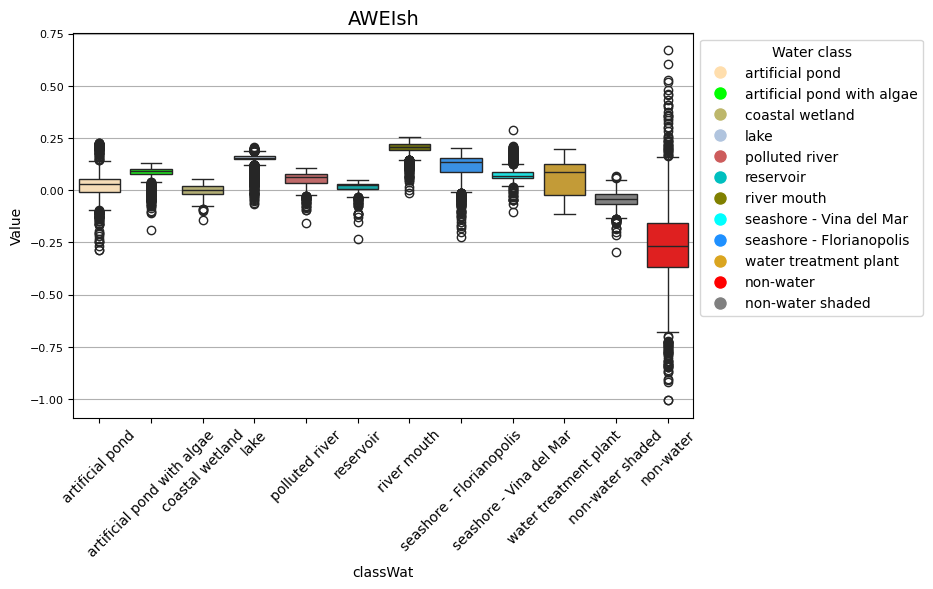

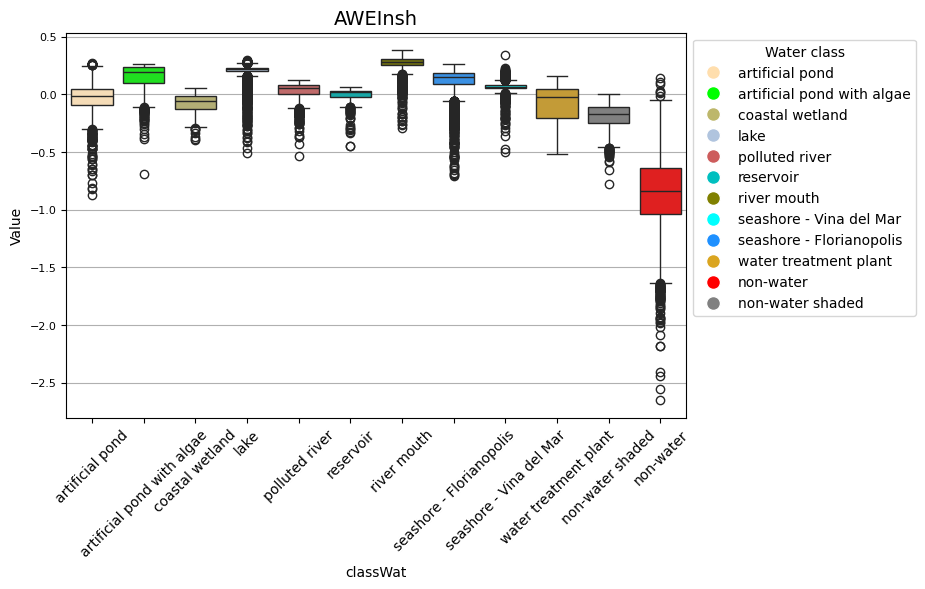

In [63]:
colorClassWat = {
    'artificial pond': 'navajowhite',
    'artificial pond with algae': 'lime',
    'coastal wetland': 'darkkhaki',
    'lake': 'lightsteelblue',
    'polluted river': 'indianred',
    'reservoir': 'c',
    'river': 'cyan',
    'river mouth': 'olive',
    'seashore - Vina del Mar': 'cyan',
    'seashore - Florianopolis': 'dodgerblue',
    'water treatment plant': 'goldenrod',
    'non-water': 'red',
    'non-water shaded': 'gray'
}

# Criar a coluna classWat ajustando sombras
df_SR['classWat'] = df_SR.apply(lambda row: 'non-water shaded' if row['shadow'] == 1 else row['classWat'], axis=1)

# Filtrar os dados para remover "river"
dfclassWat = df_SR[df_SR['classWat'] != 'noSelection']
dfclassWat = dfclassWat[dfclassWat['classWat'] != 'river']
dfclassWat = dfclassWat[['classWat', 'RWI', 'MNDWI', 'NDWI', 'AWEIsh', 'AWEInsh']]

# Derreter o dataframe para o formato longo
df_melted = dfclassWat.melt(id_vars=['classWat'], var_name='index', value_name='value')

# Criar lista de classes ordenadas alfabeticamente, deixando 'non-water shaded' e 'non-water' por último
existing_classes = df_melted['classWat'].unique()
sorted_classes = sorted([c for c in existing_classes if c not in ['non-water shaded', 'non-water']])
sorted_classes.extend([c for c in ['non-water shaded', 'non-water'] if c in existing_classes])  # Adicionar se existirem

# Criar gráfico separado para cada índice espectral
indices = df_melted['index'].unique()

for index in indices:
    plt.figure(figsize=(8, 5))  # Criar nova figura para cada índice

    # Filtrar dicionário de cores apenas para classes existentes
    filtered_palette = {k: v for k, v in colorClassWat.items() if k in existing_classes}

    # Criando o boxplot com hue e sem legenda automática
    ax = sns.boxplot(x='classWat', y='value', hue='classWat',
                     data=df_melted[df_melted['index'] == index],
                     palette=filtered_palette,
                     order=sorted_classes, legend=False)

    plt.title(index, fontsize=14)
    plt.ylabel('Value', fontsize=10)
    plt.grid(True, axis='y')

    # Criar manualmente a legenda
    legend_patches = [plt.Line2D([0], [0], marker='o', color='w', label=cls,
                                 markersize=10, markerfacecolor=color)
                      for cls, color in filtered_palette.items()]
    
    plt.legend(handles=legend_patches, title="Water class", loc="upper left", bbox_to_anchor=(1, 1))

    plt.xticks(rotation=45)
    plt.yticks(fontsize=8)

    plt.savefig(f'boxplot_{index}.png', dpi=600, bbox_inches='tight', pad_inches=0.1)
    
    plt.show()


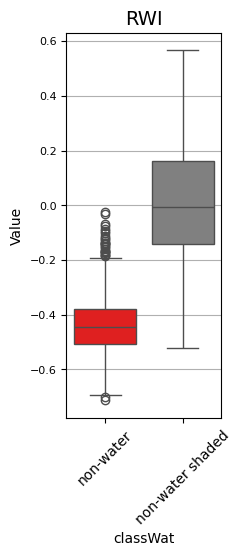

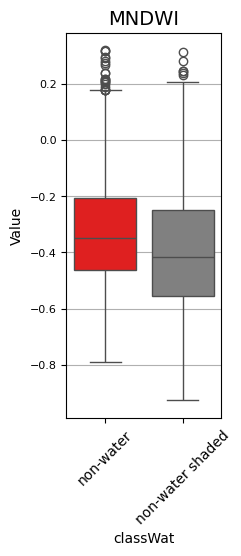

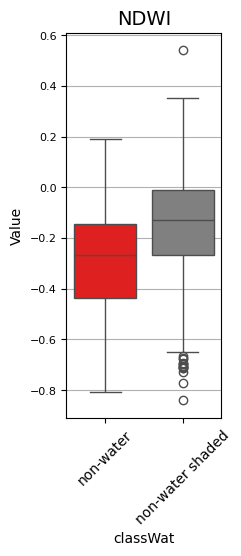

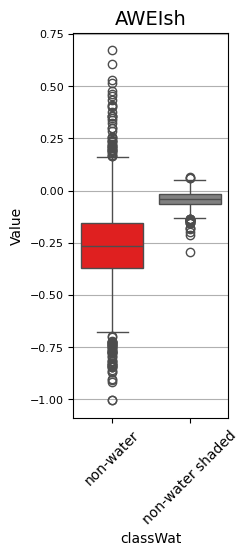

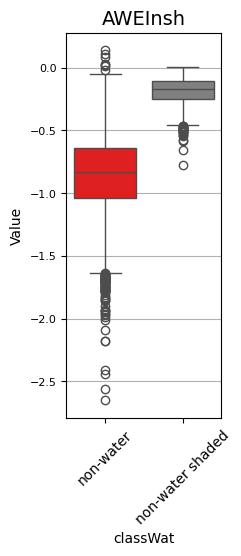

In [65]:
# Criar a coluna classWat ajustando sombras
#df_SR['classWat'] = df_SR.apply(lambda row: 'shadow' if row['shadow'] == 1 else row['classWat'], axis=1)
classNonWat
# Filtrar os dados para remover "river"
dfclassNonWat = df_SR[df_SR['classWat'] != 'noSelection']
dfclassNonWat = dfclassNonWat[dfclassNonWat['surface'] == 'non-water']
dfclassNonWat = dfclassNonWat[['classWat', 'RWI', 'MNDWI', 'NDWI', 'AWEIsh', 'AWEInsh']]

# Derreter o dataframe para o formato longo
df_melted = dfclassNonWat.melt(id_vars=['classWat'], var_name='index', value_name='value')

# Criar lista de classes ordenadas alfabeticamente, deixando 'non-water shaded' e 'non-water' por último
existing_classes = df_melted['classWat'].unique()

# Criar gráfico separado para cada índice espectral
indices = df_melted['index'].unique()

for index in indices:
    plt.figure(figsize=(2, 5))

    filtered_palette = {k: v for k, v in colorClassWat.items() if k in existing_classes}

    ax = sns.boxplot(x='classWat', y='value', 
                     data=df_melted[df_melted['index'] == index], 
                     palette=filtered_palette,
                     hue='classWat')

    plt.title(index, fontsize=14)
    plt.ylabel('Value', fontsize=10)

    plt.grid(True, axis='y')

    plt.xticks(rotation=45)
    plt.yticks(fontsize=8)

    plt.savefig('boxplot_2025-03-03_'+index, dpi=600, bbox_inches='tight', pad_inches=0.1)
    
    plt.show()


